In [9]:
# ============================================================
# 02_preprocessing_validation.ipynb — Cell 1
# Setup: imports, paths, helper functions, reload inventory
# ============================================================

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# ── Paths ─────────────────────────────────────────────────────
RAW_DIR   = Path("../data/raw/training")
SPLIT_DIR = Path("../data/splits")

# ── Helper: find .nii or .nii.gz ──────────────────────────────
def find_nii(base):
    for ext in [".nii.gz", ".nii"]:
        p = Path(str(base) + ext)
        if p.exists():
            return p
    return None

# ── Helper: load middle axial slice ───────────────────────────
def load_middle_slice(patient_dir, frame_id, is_mask=False):
    """Load the middle axial slice from a 3D NIfTI volume."""
    pid    = patient_dir.name
    suffix = "_gt" if is_mask else ""
    base   = patient_dir / f"{pid}_frame{frame_id:02d}{suffix}"
    path   = find_nii(base)
    if path is None:
        return None
    vol = nib.load(str(path)).get_fdata()
    mid = vol.shape[2] // 2
    return vol[:, :, mid]

# ── Helper: colorise segmentation mask ────────────────────────
GROUP_COLORS = {
    0: [0.0, 0.0, 0.0],   # Background — black
    1: [1.0, 0.2, 0.2],   # RV         — red
    2: [0.2, 1.0, 0.2],   # MYO        — green
    3: [0.2, 0.4, 1.0],   # LV         — blue
}

def colorise_mask(mask_2d):
    """Convert integer mask to RGB colour image."""
    rgb = np.zeros((*mask_2d.shape, 3))
    for label, color in GROUP_COLORS.items():
        rgb[mask_2d == label] = color
    return rgb

# ── Reload inventory saved by notebook 01 ─────────────────────
inventory_path = SPLIT_DIR / "dataset_inventory.csv"

assert inventory_path.exists(), (
    "dataset_inventory.csv not found.\n"
    "Please run 01_dataset_exploration.ipynb Cell 1 first."
)

df = pd.read_csv(inventory_path)
print(f"Inventory loaded: {len(df)} patients")
print(f"Groups: {df['group'].value_counts().to_dict()}")

Inventory loaded: 100 patients
Groups: {'DCM': 20, 'HCM': 20, 'MINF': 20, 'NOR': 20, 'ARV': 20}


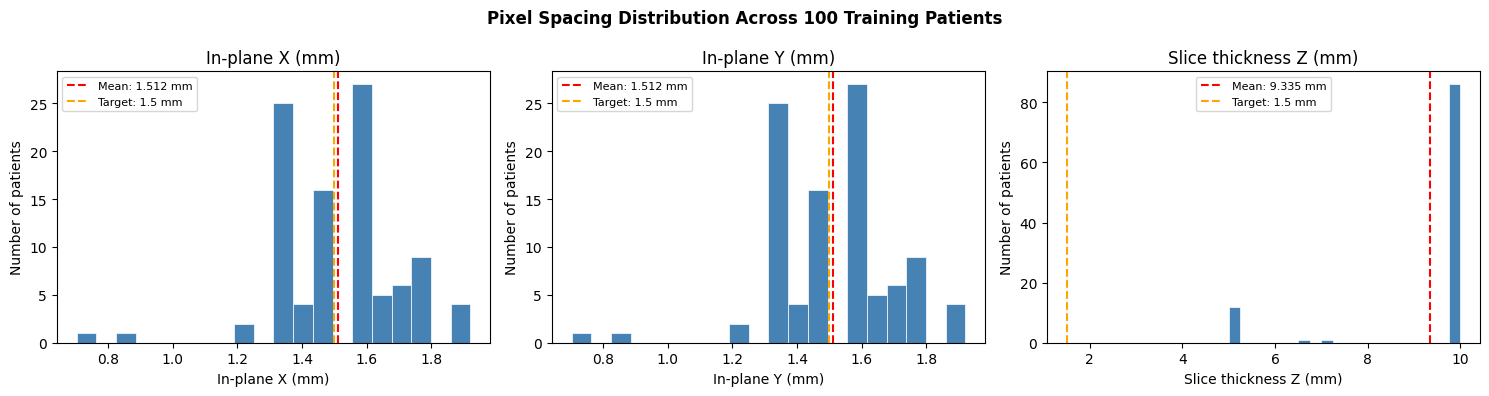


Pixel Spacing Summary:
       spacing_x_mm  spacing_y_mm  spacing_z_mm
count       100.000       100.000       100.000
mean          1.512         1.512         9.335
std           0.186         0.186         1.673
min           0.703         0.703         5.000
25%           1.367         1.367        10.000
50%           1.562         1.562        10.000
75%           1.562         1.562        10.000
max           1.920         1.920        10.000


In [10]:
# Cell 2 — Pixel spacing analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pixel Spacing Distribution Across 100 Training Patients",
             fontweight="bold")

for ax, col, label in zip(
    axes,
    ["spacing_x_mm", "spacing_y_mm", "spacing_z_mm"],
    ["In-plane X (mm)", "In-plane Y (mm)", "Slice thickness Z (mm)"]
):
    ax.hist(df[col], bins=20, color="steelblue",
            edgecolor="white", linewidth=0.5)
    ax.axvline(df[col].mean(), color="red",
               linestyle="--", label=f"Mean: {df[col].mean():.3f} mm")
    ax.axvline(1.5, color="orange",
               linestyle="--", label="Target: 1.5 mm")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of patients")
    ax.legend(fontsize=8)
    ax.set_title(label)

plt.tight_layout()
plt.savefig("../data/splits/pixel_spacing_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print("\nPixel Spacing Summary:")
print(df[["spacing_x_mm","spacing_y_mm","spacing_z_mm"]].describe().round(3))

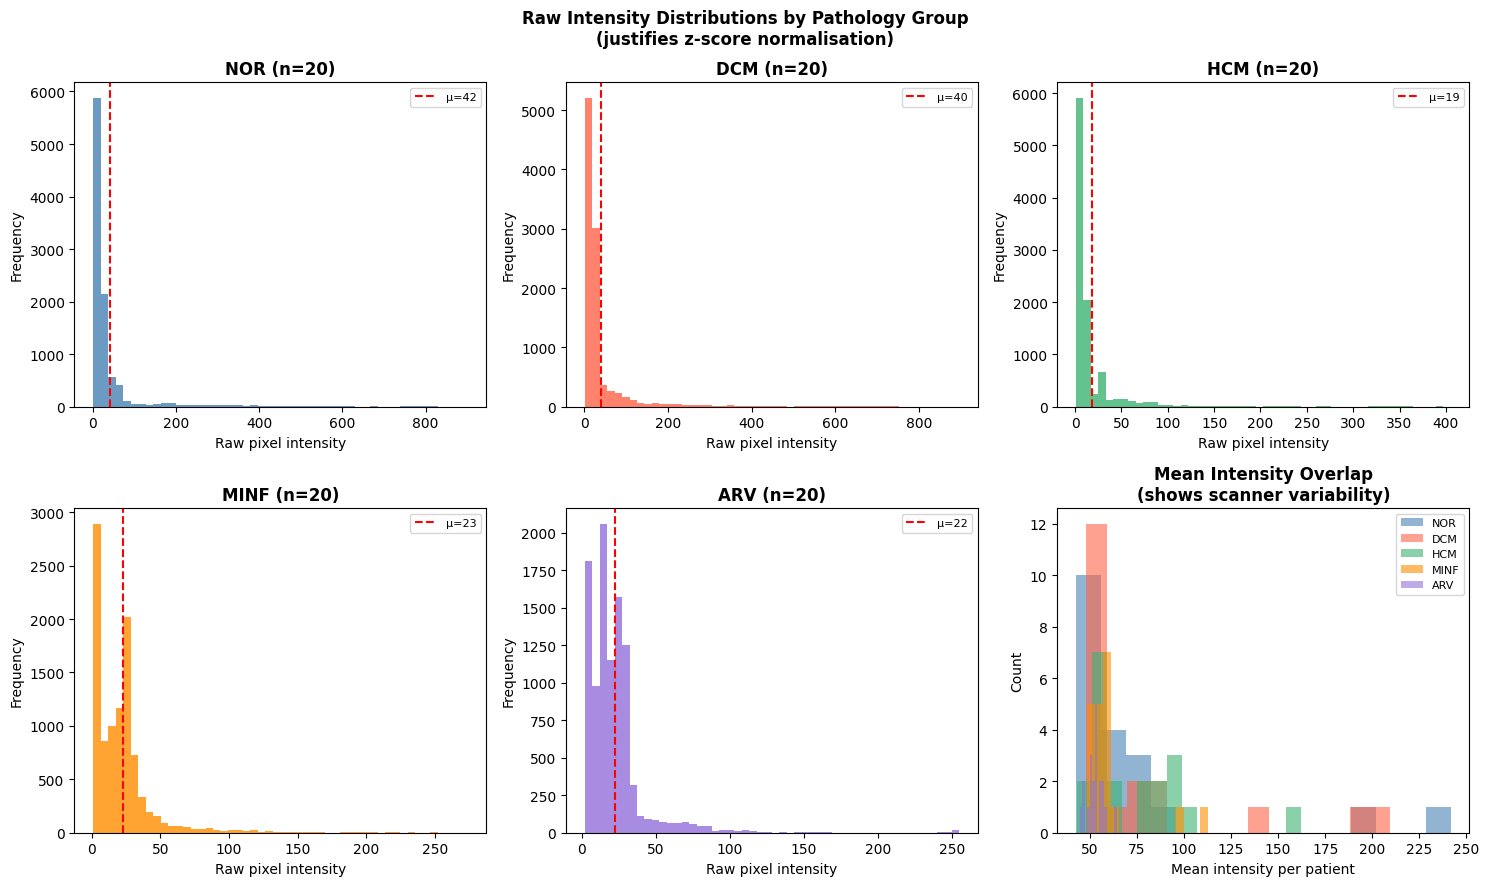

In [11]:
# Cell 3 — Intensity analysis per group

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    "Raw Intensity Distributions by Pathology Group\n"
    "(justifies z-score normalisation)",
    fontweight="bold"
)
axes = axes.flatten()

group_colors_plot = {
    "NOR": "steelblue", "DCM": "tomato",
    "HCM": "mediumseagreen", "MINF": "darkorange", "ARV": "mediumpurple"
}

for idx, group in enumerate(["NOR", "DCM", "HCM", "MINF", "ARV"]):
    ax       = axes[idx]
    grp_data = df[df["group"] == group]

    # Collect intensity values from actual slices
    intensities = []
    for _, row in grp_data.iterrows():
        pid      = row["patient_id"]
        pdir     = RAW_DIR / pid
        ed_frame = int(row["ed_frame"])
        img_sl   = load_middle_slice(pdir, ed_frame, is_mask=False)
        if img_sl is not None:
            fg = img_sl[img_sl > 0].flatten()
            intensities.extend(fg[:500].tolist())  # sample 500 pixels

    ax.hist(intensities, bins=50,
            color=group_colors_plot[group], alpha=0.8, edgecolor="none")
    ax.set_title(f"{group} (n={len(grp_data)})", fontweight="bold")
    ax.set_xlabel("Raw pixel intensity")
    ax.set_ylabel("Frequency")
    ax.axvline(np.mean(intensities), color="red",
               linestyle="--", linewidth=1.5,
               label=f"μ={np.mean(intensities):.0f}")
    ax.legend(fontsize=8)

# Overlay plot — all groups on one axis
ax = axes[5]
for group in ["NOR", "DCM", "HCM", "MINF", "ARV"]:
    grp_data   = df[df["group"] == group]
    means      = grp_data["ed_intensity_mean"]
    ax.hist(means, bins=15, alpha=0.6,
            color=group_colors_plot[group], label=group)
ax.set_title("Mean Intensity Overlap\n(shows scanner variability)",
             fontweight="bold")
ax.set_xlabel("Mean intensity per patient")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/splits/intensity_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

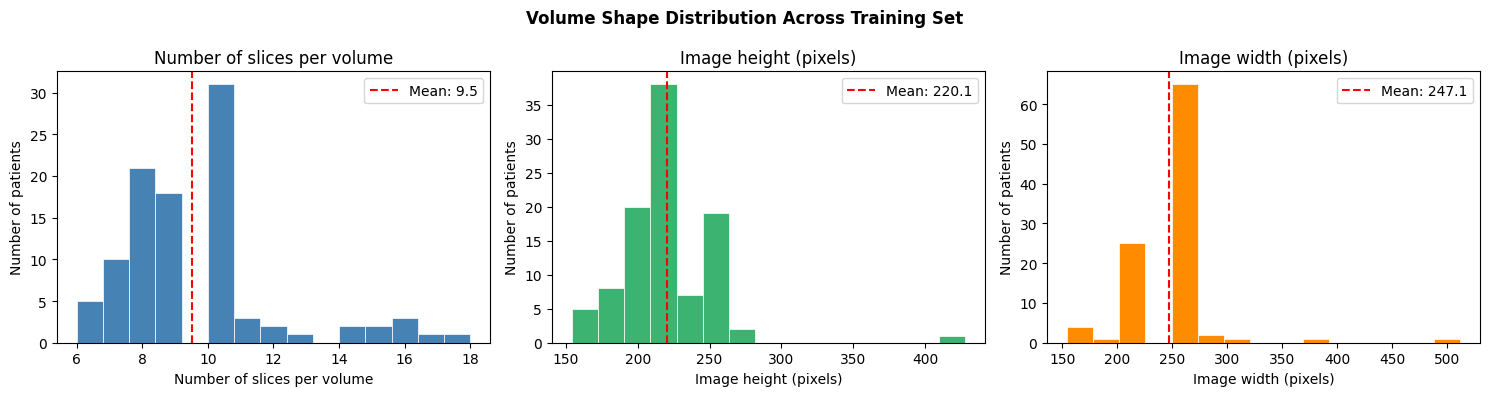


Volume Shape Summary:
       n_slices  image_rows  image_cols
count     100.0       100.0       100.0
mean        9.5       220.1       247.1
std         2.4        34.0        39.4
min         6.0       154.0       154.0
25%         8.0       208.0       224.0
50%         9.0       216.0       256.0
75%        10.0       234.0       256.0
max        18.0       428.0       512.0

Estimated training slices after split:
  80 patients × 2 phases × 9.5 mean slices
  ≈ 1521 total training slices


In [12]:
# Cell 4 — Volume shape analysis

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Volume Shape Distribution Across Training Set",
             fontweight="bold")

for ax, col, title, color in zip(
    axes,
    ["n_slices", "image_rows", "image_cols"],
    ["Number of slices per volume",
     "Image height (pixels)",
     "Image width (pixels)"],
    ["steelblue", "mediumseagreen", "darkorange"]
):
    ax.hist(df[col], bins=15, color=color,
            edgecolor="white", linewidth=0.5)
    ax.axvline(df[col].mean(), color="red", linestyle="--",
               label=f"Mean: {df[col].mean():.1f}")
    ax.set_xlabel(title)
    ax.set_ylabel("Number of patients")
    ax.legend()
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../data/splits/volume_shapes.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nVolume Shape Summary:")
print(df[["n_slices","image_rows","image_cols"]].describe().round(1))
print(f"\nEstimated training slices after split:")
print(f"  80 patients × 2 phases × {df['n_slices'].mean():.1f} mean slices")
print(f"  ≈ {int(80 * 2 * df['n_slices'].mean())} total training slices")

In [13]:
# Cell 5 — Print complete analysis summary for thesis reference

print("\n" + "="*60)
print("  ACDC DATASET ANALYSIS SUMMARY")
print("  (Reference for thesis methodology section)")
print("="*60)

print(f"""
DATASET COMPOSITION
  Total patients          : 150 (100 train, 50 test)
  Pathology groups        : 5 (balanced, 20 train / 10 test each)
  Annotated phases        : ED and ES only
  Annotation classes      : 4 (BG, RV, MYO, LV)

VOLUME CHARACTERISTICS
  Slices per volume       : {df['n_slices'].min()}–{df['n_slices'].max()} 
                            (mean {df['n_slices'].mean():.1f})
  Image dimensions        : {df['image_rows'].min()}–{df['image_rows'].max()} 
                            × {df['image_cols'].min()}–{df['image_cols'].max()} px

PIXEL SPACING
  In-plane (x,y)          : {df['spacing_x_mm'].min():.3f}–
                            {df['spacing_x_mm'].max():.3f} mm
                            (mean {df['spacing_x_mm'].mean():.3f} mm)
  Slice thickness (z)     : {df['spacing_z_mm'].min():.1f}–
                            {df['spacing_z_mm'].max():.1f} mm
  → Justifies resampling to 1.5 mm isotropic

INTENSITY STATISTICS (raw, training set ED phase)
  Min intensity           : {df['ed_intensity_min'].min():.1f}
  Max intensity           : {df['ed_intensity_max'].max():.1f}
  Mean across patients    : {df['ed_intensity_mean'].mean():.1f} 
                            ± {df['ed_intensity_mean'].std():.1f}
  → High std across patients justifies z-score normalisation

ESTIMATED TRAINING SAMPLES (after preprocessing)
  80 patients × 2 phases × ~{df['n_slices'].mean():.0f} slices
  ≈ {int(80 * 2 * df['n_slices'].mean())} training slices
  ≈ {int(20 * 2 * df['n_slices'].mean())} validation slices
""")
print("="*60)


  ACDC DATASET ANALYSIS SUMMARY
  (Reference for thesis methodology section)

DATASET COMPOSITION
  Total patients          : 150 (100 train, 50 test)
  Pathology groups        : 5 (balanced, 20 train / 10 test each)
  Annotated phases        : ED and ES only
  Annotation classes      : 4 (BG, RV, MYO, LV)

VOLUME CHARACTERISTICS
  Slices per volume       : 6–18 
                            (mean 9.5)
  Image dimensions        : 154–428 
                            × 154–512 px

PIXEL SPACING
  In-plane (x,y)          : 0.703–
                            1.920 mm
                            (mean 1.512 mm)
  Slice thickness (z)     : 5.0–
                            10.0 mm
  → Justifies resampling to 1.5 mm isotropic

INTENSITY STATISTICS (raw, training set ED phase)
  Min intensity           : 0.0
  Max intensity           : 4025.0
  Mean across patients    : 67.8 
                            ± 35.2
  → High std across patients justifies z-score normalisation

ESTIMATED TRAINING SAM